# Read KNMI observations using hydropandas

This notebook introduces how to use the `hydropandas` package to read, process and visualise KNMI data.

Martin & Onno - 2022

## <a id=top></a>Notebook contents

1. [Observation types](#Obs)
2. [Get KNMI data](#reading)
3. [Get ObsCollections](#readingOC)
4. [Precipitation data](#precipitation)
5. [Reference evaporation types](#EvapRef)
6. [Spatial interpolation of evaporation](#EvapInterp)
7. [Get transformed KNMI scenario's](#KNMITransformed)

In [4]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.interpolate import NearestNDInterpolator, RBFInterpolator
from tqdm import tqdm

import hydropandas as hpd
from hydropandas.io import knmi

In [5]:
hpd.util.get_color_logger("INFO")

<RootLogger root (INFO)>

## [Observation types](#top)<a id=Obs></a>

The hydropandas package has a function to read all kinds of KNMI observations. These are stored in an `Obs` object. There are three types of observations you can obtain from the KNMI:

- `EvaporationObs`, for evaporation time series
- `PrecipitationObs`, for precipitation time series
- `MeteoObs`, for all the other meteorological time series

Get evaporation in [m/day] for KNMI station 344 (Rotterdam Airport).

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable EV24 from 2022-01-01 to None


,EV24_ROTTERDAM_344
x,90061.930891
y,441636.854285
location,
filename,
source,KNMI
unit,m
station,344
meteo_var,EV24
,EV24
YYYYMMDD,


<Axes: xlabel='YYYYMMDD'>

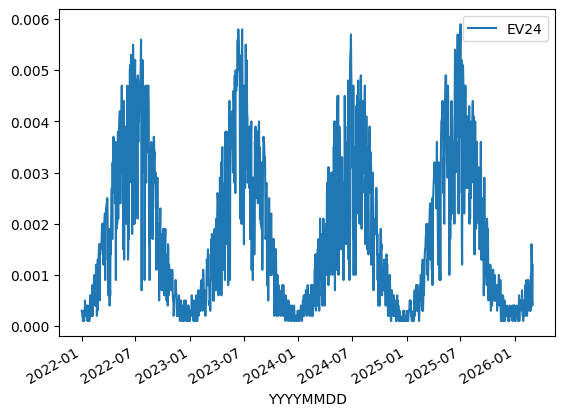

In [6]:
o = hpd.EvaporationObs.from_knmi(stn=344, start="2022")
display(o.head())
o.plot()

Get precipitation in [m/day] for KNMI station 344 (Rotterdam Airport).

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable RH from 2022-01-01 to None


,RH_ROTTERDAM_344
x,90061.930891
y,441636.854285
location,
filename,
source,KNMI
unit,m
station,344
meteo_var,RH
,RH
YYYYMMDD,


<Axes: xlabel='YYYYMMDD'>

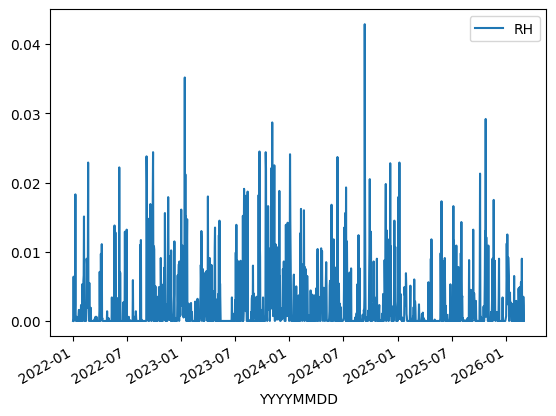

In [7]:
o = hpd.PrecipitationObs.from_knmi(stn=344, start="2022")
display(o.head())
o.plot()

Get temperature in [°C] for KNMI station 344 (Rotterdam Airport).

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable TG from 2022-01-01 to None


,TG_ROTTERDAM_344
x,90061.930891
y,441636.854285
location,
filename,
source,KNMI
unit,
station,344
meteo_var,TG
,TG
YYYYMMDD,


<Axes: xlabel='YYYYMMDD'>

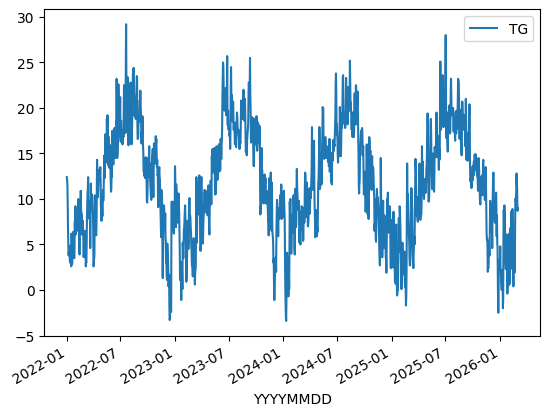

In [8]:
o = hpd.MeteoObs.from_knmi(stn=344, meteo_var="TG", start="2022")
display(o.head())
o.plot()

**attributes**

All `PrecipitationObs`, `EvaporationObs` and `MeteoObs` objects have the attributes:

* `name`: meteo variable and station name
* `x`: x-coordinate in m RD
* `y`: y-coordinate in m RD
* `station`: station number
* `unit`: measurement unit
* `meta`: dictionary with other metadata

In [9]:
print(f"name: {o.name}")
print(f"x,y: {(o.x, o.y)}")
print(f"station: {o.station}")
print("unit", o.unit)
print("metadata:")
for key, item in o.meta.items():
    print(f"    {key}: {item}")

name: TG_ROTTERDAM_344
x,y: (90061.9308913925, 441636.8542853093)
station: 344
unit 
metadata:
    location: ROTTERDAM
    TG: Etmaalgemiddelde temperatuur (in graden Celsius) / Daily mean temperature in (degrees Celsius)


## [Get KNMI data](#top)<a id=reading></a>

The `from_knmi` method can be used to obtain one type of measurements at one station. There are two ways to select the station.

1. with the station number `stn`
2. by specifying the `xy` coordinates, the station nearest to this coordinates is used.

Below both methods are used to obtain precipitation measurements. Notice that they return the same data because station 344 is nearest to the given xy coordinates.

In [10]:
o1 = hpd.PrecipitationObs.from_knmi(stn=344)
o2 = hpd.PrecipitationObs.from_knmi(xy=(90600, 442800))
o1.equals(o2)

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable RH from None to None
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (90600, 442800) and meteovariable RH


True

**read options**

The `from_knmi` method has other optional arguments:

- `stn`: station number.
- `start`: the start date of the time series you want, default is 1st of January 2019.
- `end`: the end date of the time series you want, default is today.
- `fill_missing_obs`: option to fill missing values with values from the nearest KNMI station. If measurements are filled an extra column is added to the time series in which the station number is shown that was used to fill a particular missing value.
- `interval`: time interval of the time series, default is 'daily'
- `use_api`: select the method to obtain the data, default is 'True'
- `raise_exception`: option to raise an error when the requested time series is empty.
***

The 3 examples below give a brief summary of these options

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable TG from 1960-01-01 to None


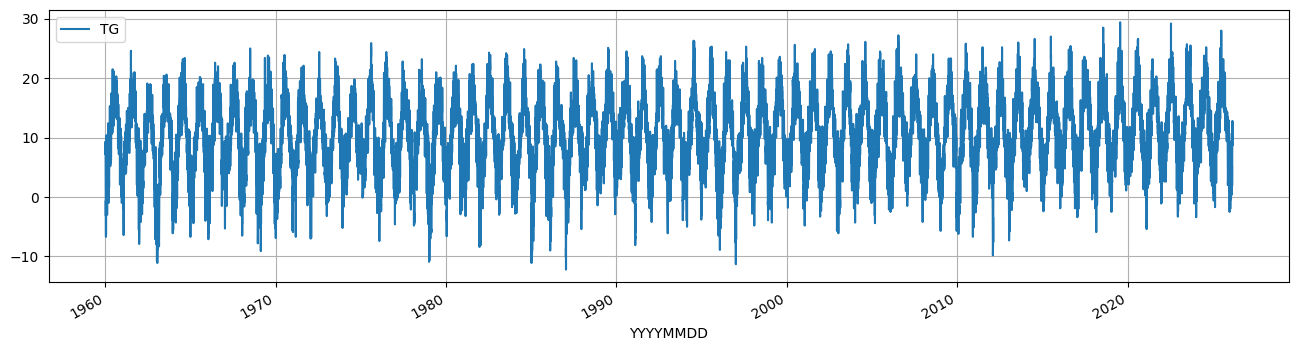

In [11]:
# example 1 get daily average temperature (TG) from 1900 till now
o_t = hpd.MeteoObs.from_knmi("TG", stn=344, start="1960")
o_t.plot(figsize=(16, 4), grid=True);

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 892 and variable RD from 1972-01-01 to 2023-01-01
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 892 and variable RD from 1972-01-01 to 2023-01-01
INFO:hydropandas.io.knmi._add_missing_indices:station 892 has no measurements before 1993-11-01 09:00:00
INFO:hydropandas.io.knmi.fill_missing_measurements:Filled 7975 observations from station 827 TILBURG -> 892 GIERSBERGEN


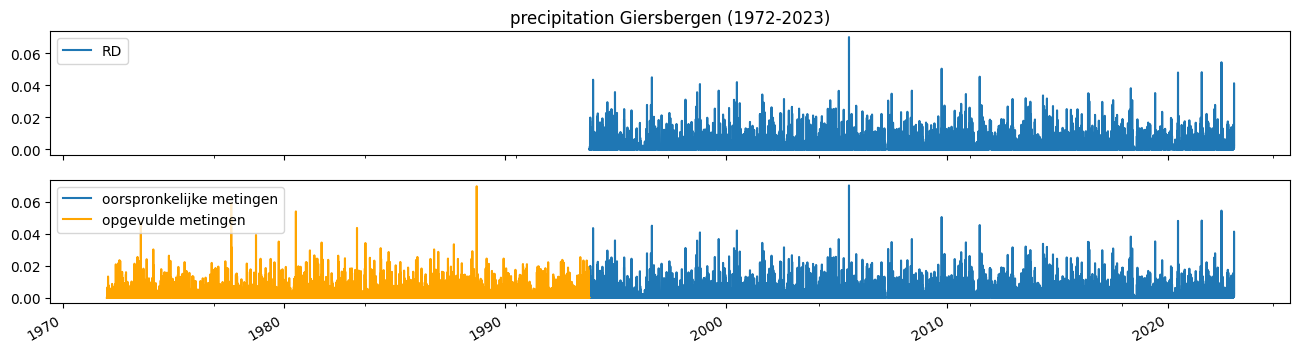

In [12]:
# example 2 get daily average precipitation from 1972 with and without filling missing measurements
f, axes = plt.subplots(figsize=(16, 6), nrows=2, sharex=True, sharey=True)

o_rd = hpd.PrecipitationObs.from_knmi(
    "RD", stn=892, start="1972", end="2023", fill_missing_obs=False
)
o_rd.plot(figsize=(16, 4), ax=axes[0])

o_rd_filled = hpd.PrecipitationObs.from_knmi(
    "RD", stn=892, start="1972", end="2023", fill_missing_obs=True
)

o_rd_filled.loc[o_rd_filled["station"] == "892", "RD"].plot(
    ax=axes[1], label="oorspronkelijke metingen"
)
o_rd_filled.loc[o_rd_filled["station"] != "892", "RD"].plot(
    ax=axes[1], color="orange", label="opgevulde metingen"
)
axes[0].set_title("precipitation Giersbergen (1972-2023)")
axes[1].legend();

In [13]:
# see the station_opvulwaarde
display(o_rd_filled.head())

PrecipitationObs RD_GIERSBERGEN_892
-----metadata------
name : RD_GIERSBERGEN_892 
x : 138500.0 
y : 407500.0 
location :  
filename :  
source : KNMI 
unit : m 
station : 892 
meteo_var : RD 

-----time series------
                      RD station
1972-01-01 09:00:00  0.0     827
1972-01-02 09:00:00  0.0     827
1972-01-03 09:00:00  0.0     827
1972-01-04 09:00:00  0.0     827
1972-01-05 09:00:00  0.0     827

In [14]:
# example 3 get evaporation
logging.getLogger().getEffectiveLevel()
logging.getLogger().setLevel(logging.INFO)

o_ev = hpd.EvaporationObs.from_knmi(
    stn=344, start="1972", end="2023", fill_missing_obs=True
)
o_ev

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable EV24 from 1972-01-01 to 2023-01-01
INFO:hydropandas.io.knmi._add_missing_indices:station 344 has no measurements before 1987-09-12 01:00:00
INFO:hydropandas.io.knmi.fill_missing_measurements:Filled 246 observations from station 210 VALKENBURG -> 344 ROTTERDAM
INFO:hydropandas.io.knmi.fill_missing_measurements:Filled 64 observations from station 348 CABAUW-MAST -> 344 ROTTERDAM
INFO:hydropandas.io.knmi.fill_missing_measurements:Filled 5499 observations from station 260 DE-BILT -> 344 ROTTERDAM


EvaporationObs EV24_ROTTERDAM_344
-----metadata------
name : EV24_ROTTERDAM_344 
x : 90061.9308913925 
y : 441636.8542853093 
location :  
filename :  
source : KNMI 
unit : m 
station : 344 
meteo_var : EV24 

-----time series------
                       EV24 station
1972-01-01 01:00:00  0.0002     260
1972-01-02 01:00:00  0.0002     260
1972-01-03 01:00:00  0.0002     260
1972-01-04 01:00:00  0.0000     260
1972-01-05 01:00:00  0.0000     260
...                     ...     ...
2022-12-28 01:00:00  0.0003     344
2022-12-29 01:00:00  0.0001     344
2022-12-30 01:00:00  0.0002     344
2022-12-31 01:00:00  0.0001     344
2023-01-01 01:00:00  0.0001     344

[18629 rows x 2 columns]

## [Get ObsCollections](#top)<a id=readingOC></a>

You can read multiple `Observation` objects at once using the `hpd.read_knmi` method. The observations are stored in an `ObsCollection` object. Below an example to obtain precipitation (RH) and evaporation (EV24) from the measurement stations Rotterdam (344) and De Bilt (260). 

In [15]:
oc = hpd.read_knmi(stns=[344, 260], meteo_vars=["RH", "EV24"])
oc

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable RH from None to None
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable RH from None to None
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable EV24 from None to None
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable EV24 from None to None


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
RH_ROTTERDAM_344,90061.930891,441636.854285,,,KNMI,m,344,RH,PrecipitationObs RH_ROTTERDAM_344 -----metadat...
RH_DE-BILT_260,140565.152506,456790.999119,,,KNMI,m,260,RH,PrecipitationObs RH_DE-BILT_260 -----metadata-...
EV24_ROTTERDAM_344,90061.930891,441636.854285,,,KNMI,m,344,EV24,EvaporationObs EV24_ROTTERDAM_344 -----metadat...
EV24_DE-BILT_260,140565.152506,456790.999119,,,KNMI,m,260,EV24,EvaporationObs EV24_DE-BILT_260 -----metadata-...


other options in the `read_knmi` function are:

- specify `locations` as a dataframe with x, y coordinates (RD_new), the function will find the nearest KNMI station for every location.
- specify `xmid` and `ymid` which are 2 arrays corresponding to a structured grid to obtain the nearest KNMI station for every cell in the grid.

In [16]:
locations = pd.DataFrame(index=["Rotterdam"], data={"x": 90600, "y": 442800})
display(locations)
hpd.read_knmi(locations=locations, meteo_vars=["RH"])

,x,y
Rotterdam,90600,442800


INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable RH from None to None


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
RH_ROTTERDAM_344,90061.930891,441636.854285,,,KNMI,m,344,RH,PrecipitationObs RH_ROTTERDAM_344 -----metadat...


In [17]:
hpd.read_knmi(xy=((90600, 442800),), meteo_vars=["RH"])

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 344 and variable RH from None to None


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
RH_ROTTERDAM_344,90061.930891,441636.854285,,,KNMI,m,344,RH,PrecipitationObs RH_ROTTERDAM_344 -----metadat...


## [Precipitation](#top)<a id=precipitation></a>

Using hydropandas 3 different precipitation products can be accessed:

1. Daily data from a meteorological station
2. Daily data from a neerslag (precipitation) station
3. Hourly data from a meteorological station

All three products can be obtained using the `from_knmi` method. Product 1 and 2 can also be accessed without the api.

By default data is used from a meteorological station. Specify `meteo_var='RD'` to access data from a neerslag (precipitation) station.

In [18]:
start = "2010-1-1"
end = "2010-1-10"

# daily meteo station (default)
precip1 = hpd.PrecipitationObs.from_knmi(stn=260, start=start, end=end)

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable RH from 2010-01-01 to 2010-01-10


In [19]:
# daily neerslag station
precip2 = hpd.PrecipitationObs.from_knmi(meteo_var="RD", stn=550, start=start, end=end)

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 550 and variable RD from 2010-01-01 to 2010-01-10


In [20]:
# hourly meteo station (only works with api)
precip3 = hpd.PrecipitationObs.from_knmi(
    stn=260,
    start=start,
    end=end,
    interval="hourly",
)

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable RH from 2010-01-01 to 2010-01-10


In [21]:
# daily meteo station without api
precip4 = hpd.PrecipitationObs.from_knmi(
    stn=260,
    start=start,
    end=end,
    use_api=False,
)

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable RH from 2010-01-01 to 2010-01-10


In [22]:
# daily neerslag station without api
precip5 = hpd.PrecipitationObs.from_knmi(
    meteo_var="RD",
    stn=550,
    start=start,
    end=end,
    use_api=False,
)

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 550 and variable RD from 2010-01-01 to 2010-01-10


Below are the differences between the precipitation estimates from different station types.

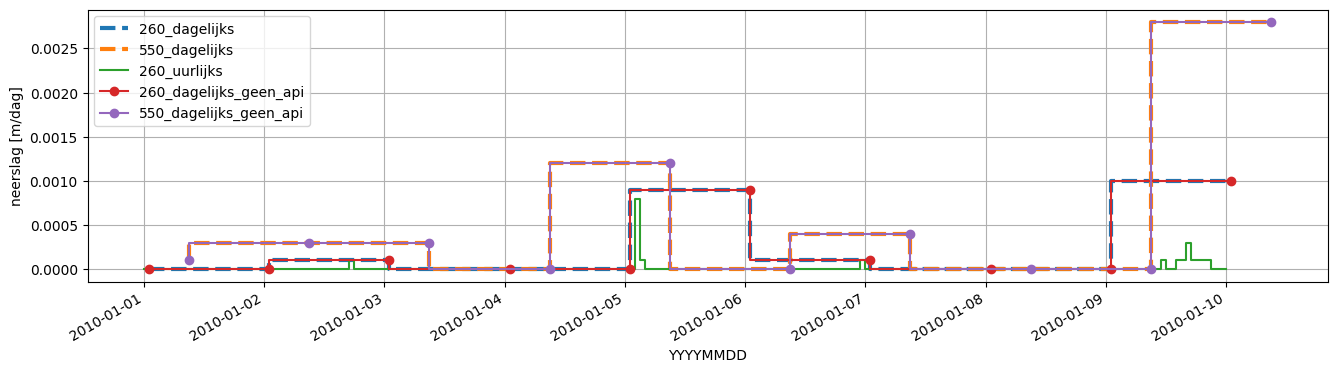

In [23]:
fig, ax = plt.subplots(figsize=(16, 4))
precip1["RH"].plot(
    ax=ax,
    drawstyle="steps",
    ls="--",
    lw=3,
    label=str(precip1.station) + "_dagelijks",
)

precip2["RD"].plot(
    ax=ax,
    drawstyle="steps",
    ls="--",
    lw=3,
    label=str(precip2.station) + "_dagelijks",
)

precip3["RH"].plot(
    ax=ax,
    drawstyle="steps",
    label=str(precip3.station) + "_uurlijks",
)

precip4["RH"].plot(
    ax=ax,
    drawstyle="steps",
    marker="o",
    label=str(precip4.station) + "_dagelijks_geen_api",
)

precip5["RD"].plot(
    ax=ax,
    drawstyle="steps",
    marker="o",
    label=str(precip5.station) + "_dagelijks_geen_api",
)


ax.legend()
ax.grid()
ax.set_ylabel("neerslag [m/dag]");

The locations of the stations can be plotted onto a map using the contextily package.

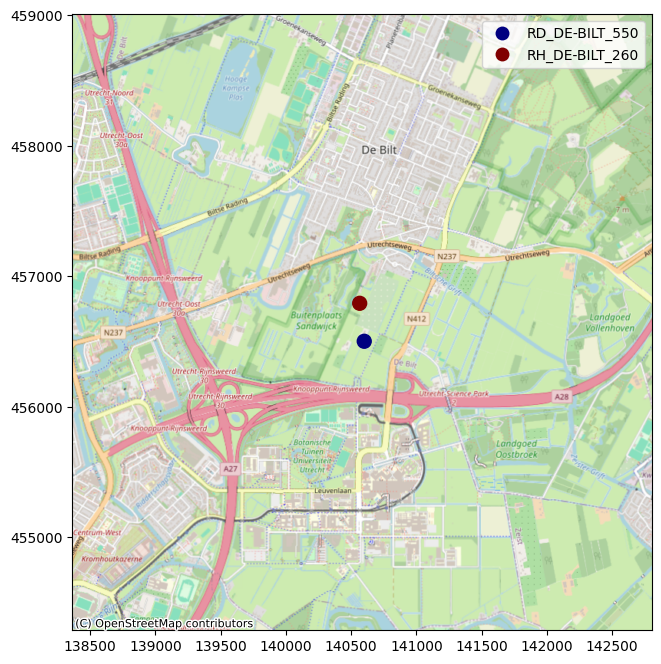

In [24]:
import contextily as cx

oc = hpd.ObsCollection([precip1, precip2])

gdf = oc.to_gdf()

gdf = gdf.set_crs(28992)

gdf["name"] = gdf.index

ax = gdf.buffer(2000).plot(alpha=0, figsize=(8, 8))

gdf.plot("name", ax=ax, cmap="jet", legend=True, markersize=100)


cx.add_basemap(ax, crs=28992, source=cx.providers.OpenStreetMap.Mapnik)

## [Evaporation](#top)<a id=EvapRef></a>

KNMI provides the Makking reference evaporation (meteo_var EV24). Hydropandas provides a posssibility to calculate three different types of reference evaporation from data of KNMI meteo stations:

- Penman
- Hargreaves
- Makkink (in the same way as KNMI)

These three types of reference evaporation are calculated the same way as described by [Allen et al. 1990](https://www.fao.org/3/x0490E/x0490e07.htm#solar%20radiation) and [STOWA rapport](https://edepot.wur.nl/163482). Be aware that the last report is written in Dutch and contains errors in the units.

The following variables from the KNMI are used for each reference evaporation type:

- Penman: average (TG), minimum (TN) and maximum (TX) temperature, de global radiation (Q), de windspeed (FG) en de relative humidity (PG).
- Hargreaves: average (TG), minimum (TN) and maximum (TX) temperature
- Makkink: average temperature (TG) and global radiation (Q)

### Comparison Makkink

Lets compare Hypdropandas Makkink verdamping evaporation with the EV24 Makkink verdamping of the KNMI. When Hydropandas Makkink evaporation is rounded (on 4 decimals), the estimate is the same as for the KNMI estimate.

In [25]:
ev24 = hpd.EvaporationObs.from_knmi(
    stn=260, start="2022-1-1"
)  # et_type='EV24' by default
makk = hpd.EvaporationObs.from_knmi(meteo_var="makkink", stn=260, start="2022-1-1")

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable EV24 from 2022-01-01 to None
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable makkink from 2022-01-01 to None


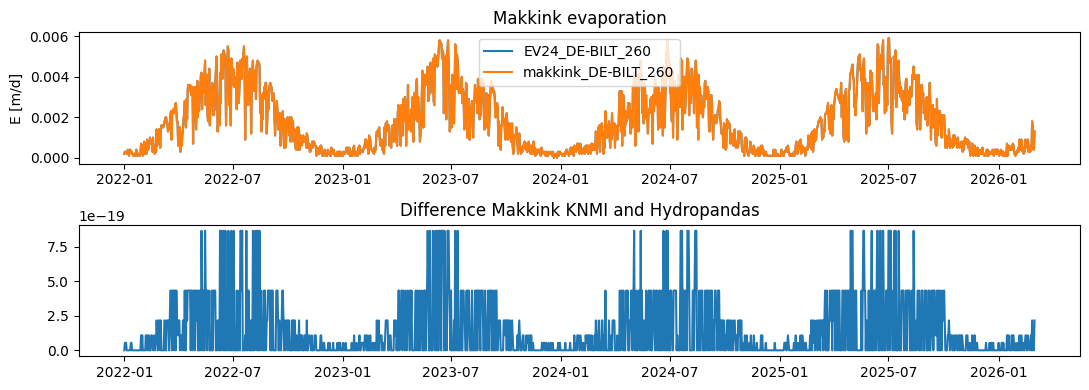

In [26]:
f, ax = plt.subplots(2, figsize=(11, 4))
ax[0].plot(ev24, label=ev24.name)
ax[0].plot(makk.round(4), label=makk.name)
ax[0].set_ylabel("E [m/d]")
ax[0].set_title("Makkink evaporation")
ax[0].legend()
ax[1].plot(ev24["EV24"] - makk["makkink"].round(4))
ax[1].set_title("Difference Makkink KNMI and Hydropandas")
f.tight_layout()

### Comparison Penman, Makkink en Hargreaves
On average Penman gives a higher estimate for reference evaporation than Makkink (~0.55mm). This can be explained by the fact that Penman takes into account windspeed and Makkink ignores this proces. Hargreaves is a very simple way of estimation the evaporation, only taking into account temperature and extraterrestial radiation. Therefore it gives a lower estimate for the reference evporatoin compared to the two other methods (~-0.35mm wrt Makkink).

In [27]:
penm = hpd.EvaporationObs.from_knmi(
    meteo_var="penman", stn=260, start="2022-1-1"
).squeeze()
harg = hpd.EvaporationObs.from_knmi(
    meteo_var="hargreaves", stn=260, start="2022-1-1"
).squeeze()

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable penman from 2022-01-01 to None
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable hargreaves from 2022-01-01 to None


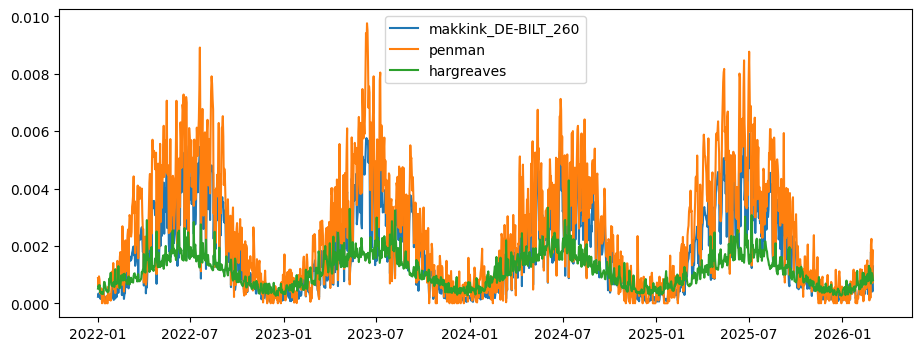

In [28]:
f, ax = plt.subplots(figsize=(11, 4))
ax.plot(makk, label=makk.name)
ax.plot(penm, label=penm.name)
ax.plot(harg, label=harg.name)
ax.legend()

## [Spatial interpolate (Makkink) Evaporation?](#top)<a id=EvapInterp></a>

Does interpolation matter? There are ways to interpolate evaporation datasets. However currently the nearest station is always used in HydroPandas' methods. Does this give different results? First lets look spatially.

Get all stations where EV24 is measured

In [29]:
stns = knmi.get_stations(meteo_var="EV24").sort_index()

Collect all EV24 data ever measured by KNMI

In [30]:
tmin = "1950-01-01"
tmax = "2022-04-11"

# empty dataframe
df = pd.DataFrame(
    columns=stns.index
)  # index=pd.date_range(start=tmin, end=tmax, freq='H')

for stn in tqdm(stns.index):
    df_stn = hpd.MeteoObs.from_knmi(
        meteo_var="EV24", stn=stn, fill_missing_obs=False, start=tmin, end=tmax
    )
    df[stn] = df_stn

df

  0%|          | 0/34 [00:00<?, ?it/s]

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 210 and variable EV24 from 1950-01-01 to 2022-04-11


  3%|▎         | 1/34 [00:00<00:26,  1.25it/s]

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 215 and variable EV24 from 1950-01-01 to 2022-04-11


  6%|▌         | 2/34 [00:01<00:18,  1.78it/s]

...

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 380 and variable EV24 from 1950-01-01 to 2022-04-11


 97%|█████████▋| 33/34 [00:21<00:00,  1.36it/s]

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 391 and variable EV24 from 1950-01-01 to 2022-04-11


100%|██████████| 34/34 [00:22<00:00,  1.51it/s]


,210,215,235,240,249,251,257,260,265,267,...,330,344,348,350,356,370,375,377,380,391
YYYYMMDD,,,,,,,,,,,,,,,,,,,,,
1987-03-26 01:00:00,0.0006,NaN,0.0006,NaN,NaN,NaN,NaN,0.0005,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0008,NaN,NaN,0.0010,NaN
1987-03-27 01:00:00,0.0016,NaN,0.0015,NaN,NaN,NaN,NaN,0.0016,NaN,NaN,...,NaN,NaN,0.0016,NaN,NaN,0.0017,NaN,NaN,0.0024,NaN
1987-03-28 01:00:00,0.0008,NaN,0.0007,NaN,NaN,NaN,NaN,0.0007,NaN,NaN,...,NaN,NaN,0.0007,NaN,NaN,0.0005,NaN,NaN,0.0008,NaN
1987-03-29 01:00:00,0.0013,NaN,0.0007,NaN,NaN,NaN,NaN,0.0010,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0013,NaN,NaN,0.0014,NaN
1987-03-30 01:00:00,0.0019,NaN,0.0021,NaN,NaN,NaN,NaN,0.0016,NaN,NaN,...,NaN,NaN,0.0017,NaN,NaN,0.0015,NaN,NaN,0.0018,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-29 01:00:00,0.0023,0.0022,0.0020,0.0020,0.0015,0.0018,0.0014,0.0022,NaN,0.0021,...,0.0023,0.0026,0.0023,0.0018,0.0022,0.0024,0.0019,0.0025,0.0025,0.0023
2016-04-30 01:00:00,0.0023,0.0021,0.0025,0.0020,0.0022,0.0027,0.0022,0.0014,NaN,0.0021,...,0.0025,0.0021,0.0016,0.0014,0.0012,0.0015,0.0014,0.0010,0.0010,0.0009
2016-05-01 01:00:00,0.0023,0.0022,0.0029,0.0022,0.0021,0.0028,0.0026,0.0023,NaN,0.0026,...,0.0027,0.0025,0.0022,0.0021,0.0021,0.0022,0.0021,0.0009,0.0011,0.0015


According to the KNMI, thin plate spline is the best way to interpolate Makkink evaporation. Thats also how they provide the gridded Makkink evaporation : 

- [Evaporation Dataset - gridded daily Makkink evaporation for the Netherlands](https://dataplatform.knmi.nl/dataset/ev24-2)
- [Interpolation of Makkink evaporation in the
Netherlands - Paul Hiemstra and Raymond Sluiter (2011)](https://cdn.knmi.nl/knmi/pdf/bibliotheek/knmipubTR/TR327.pdf)

100%|██████████| 6/6 [00:00<00:00, 11.72it/s]


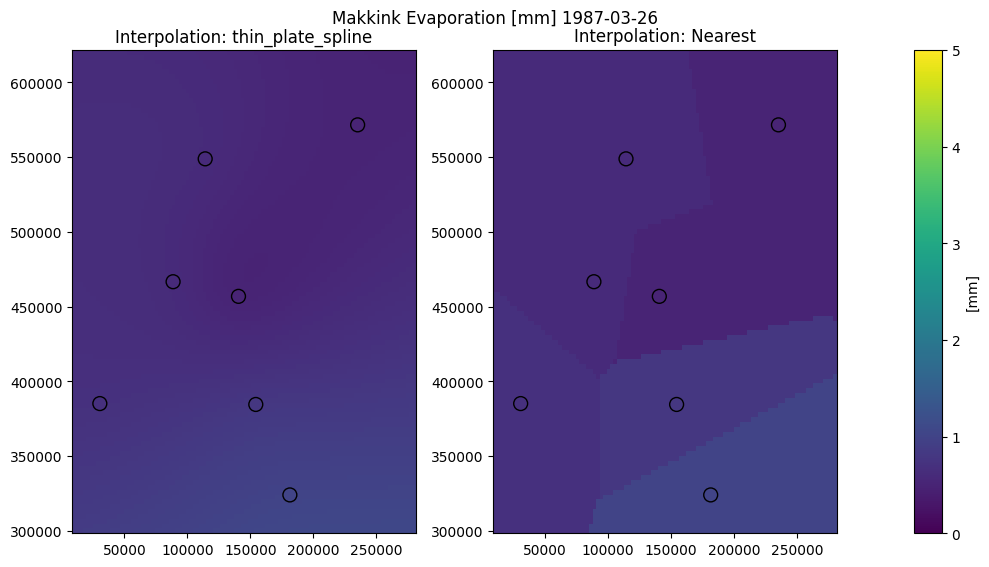

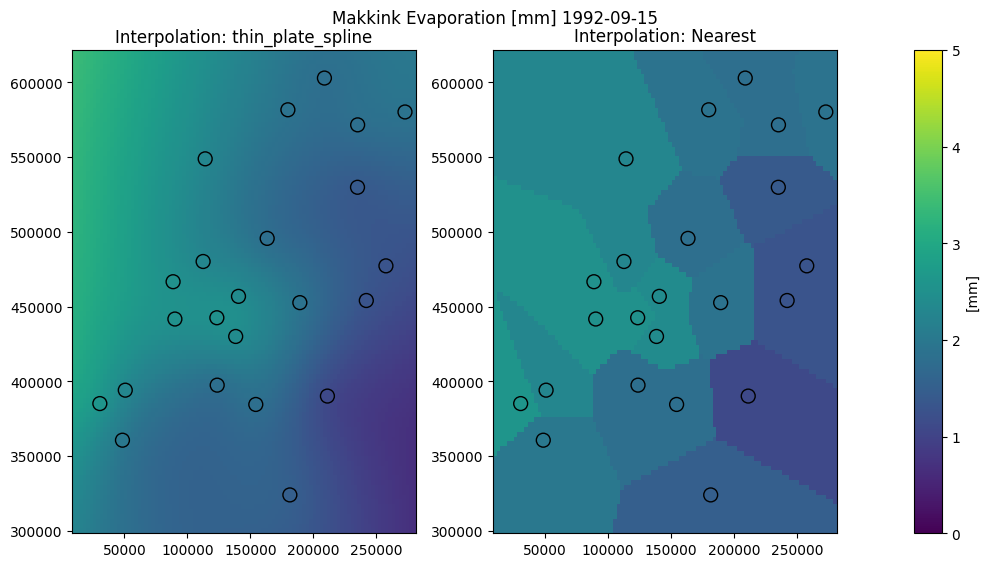

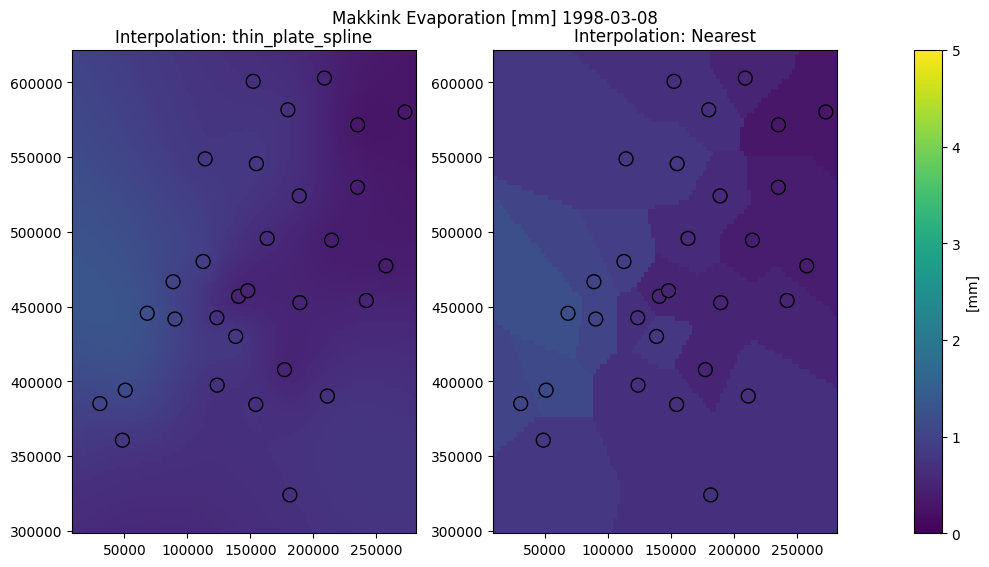

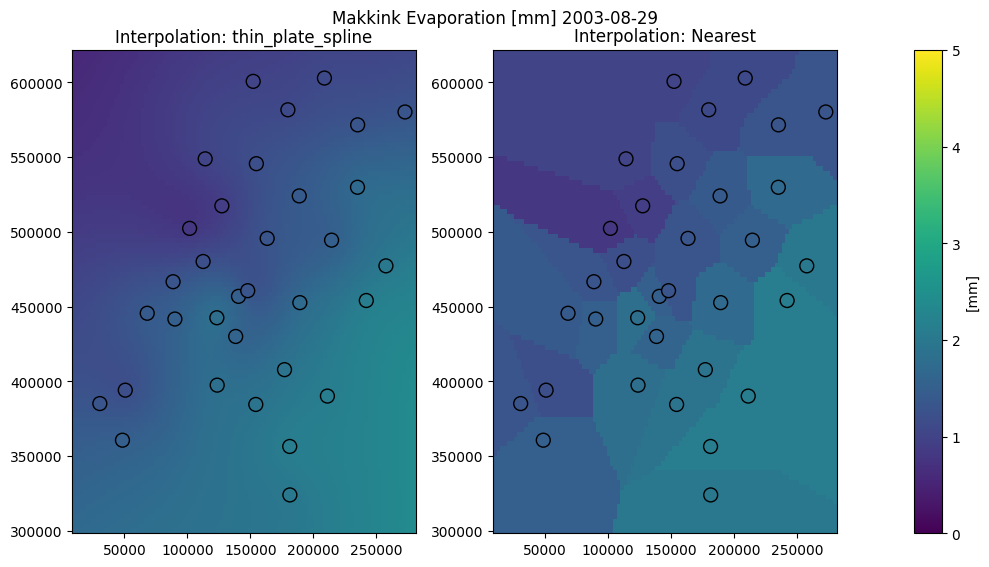

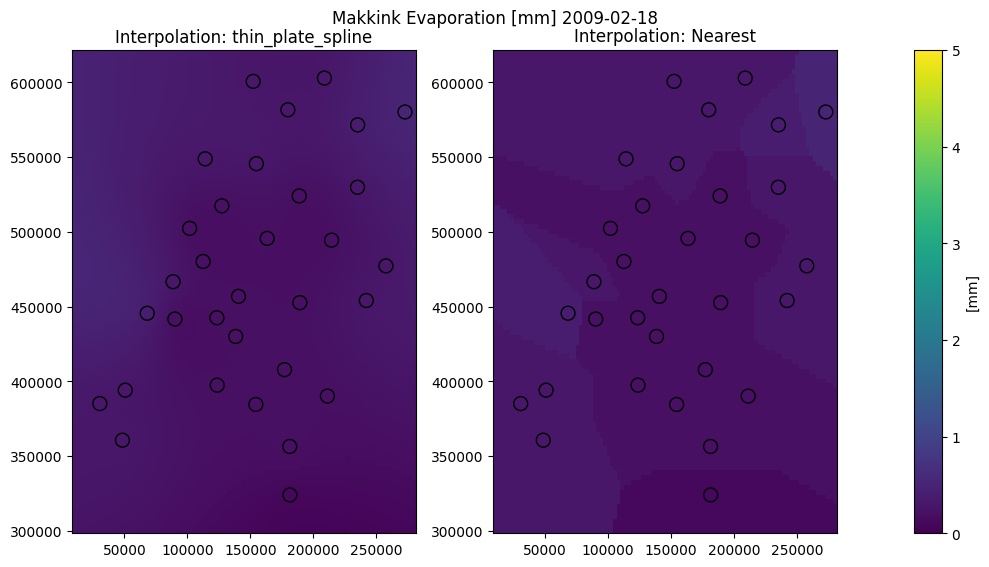

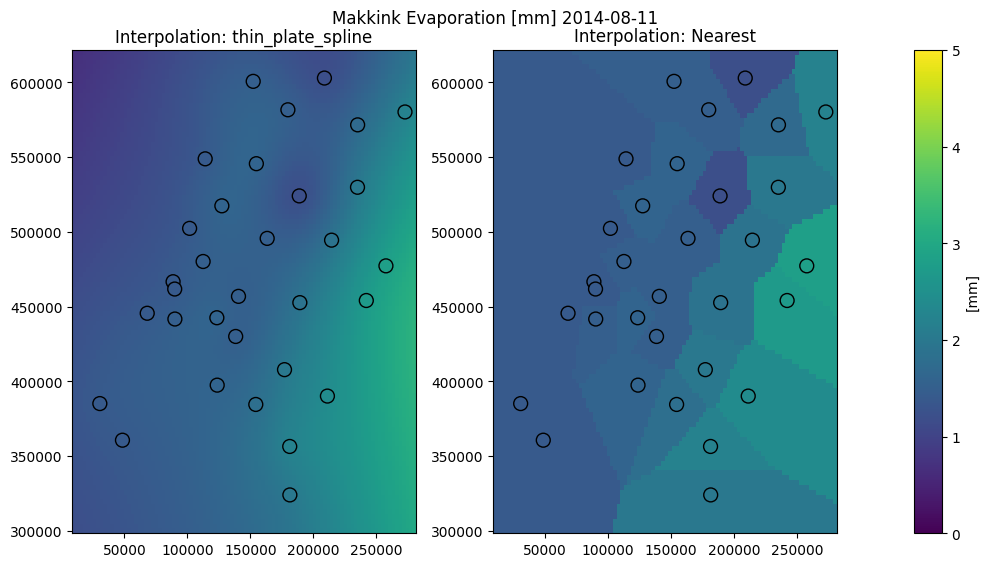

In [31]:
xy = stns.loc[df.columns, ["x", "y"]]

for idx in tqdm(df.index[0 : len(df) : 2000]):
    # get all stations with values for this date
    val = df.loc[idx].dropna() * 1000  # mm
    # get stations for this date
    coor = xy.loc[val.index].to_numpy()
    if (
        len(val) < 3
    ):  # if there are less than 3 stations, thin plate spline does not work
        # options: linear, multiquadric, gaussian,
        kernel = "linear"

    else:
        kernel = "thin_plate_spline"
        # options:
        # 'inverse_quadratic', 'linear', 'multiquadric', 'gaussian',
        # 'inverse_multiquadric', 'cubic', 'quintic', 'thin_plate_spline'

    # create an scipy interpolator
    rbf = RBFInterpolator(coor, val.to_numpy(), epsilon=1, kernel=kernel)

    nea = NearestNDInterpolator(coor, val.to_numpy())

    # interpolate on grid of the Netherlands
    grid = np.mgrid[10000:280000:100j, 300000:620000:100j]
    grid2 = grid.reshape(2, -1).T  # interpolator only takes array [[x0, y0],
    #  [x1, y1]]
    val_rbf = rbf.__call__(grid2).reshape(100, 100)
    val_nea = nea.__call__(grid2).reshape(100, 100)

    # create figure
    fig, ax = plt.subplot_mosaic("AAAABBBBC", figsize=(10, 5.925))
    fig.suptitle(f"Makkink Evaporation [mm] {idx.date()}", y=0.95)
    vmin = 0
    vmax = 5

    ax["A"].set_title(f"Interpolation: {kernel}")
    ax["A"].pcolormesh(grid[0], grid[1], val_rbf, vmin=vmin, vmax=vmax)
    ax["B"].set_title("Interpolation: Nearest")
    ax["B"].pcolormesh(grid[0], grid[1], val_nea, vmin=vmin, vmax=vmax)
    ax["A"].scatter(*coor.T, c=val, s=100, ec="k", vmin=vmin, vmax=vmax)
    p = ax["B"].scatter(*coor.T, c=val, s=100, ec="k", vmin=vmin, vmax=vmax)
    cb = fig.colorbar(p, cax=ax["C"])
    cb.set_label("[mm]")
    fig.tight_layout()

The same method is implemented in Hydropandas for an ObsCollection.

In [32]:
sd = "2022-01-01"
ed = "2022-12-31"
oc = hpd.read_knmi(
    stns=stns.index, starts=sd, ends=ed, meteo_vars=["EV24"], raise_exceptions=False
)
oc_et = oc.interpolate(xy=[(100000, 330000)])
eti = oc_et.iloc[0].obs
eti

INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 210 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 215 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 235 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 240 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 249 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 251 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 257 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 260 and variable EV24 from 2022-01-01 to 2022-12-31
INFO:hydropandas.io.knmi.get_knmi_obs:get data from station 265 and variable EV24 from 2022-01-01 to 202

,100000_330000
x,100000
y,330000
location,
filename,
source,interpolation
unit,
station,NaN
meteo_var,EV24
,100000_330000
YYYYMMDD,


In [33]:
etn = hpd.MeteoObs.from_knmi(
    xy=(100000, 330000), start=sd, end=ed, meteo_var="EV24", fill_missing_obs=True
)
etn

INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (100000, 330000) and meteovariable EV24


MeteoObs EV24_WESTDORPE_319
-----metadata------
name : EV24_WESTDORPE_319 
x : 48425.3620486635 
y : 360618.7134562104 
location :  
filename :  
source : KNMI 
unit : m 
station : 319 
meteo_var : EV24 

-----time series------
                       EV24 station
2022-01-01 01:00:00  0.0002     319
2022-01-02 01:00:00  0.0005     319
2022-01-03 01:00:00  0.0004     319
2022-01-04 01:00:00  0.0002     319
2022-01-05 01:00:00  0.0002     319
...                     ...     ...
2022-12-27 01:00:00  0.0003     319
2022-12-28 01:00:00  0.0003     319
2022-12-29 01:00:00  0.0001     319
2022-12-30 01:00:00  0.0002     319
2022-12-31 01:00:00  0.0001     319

[365 rows x 2 columns]

As can be seen, for one location the interpolation method is significantly slower. Lets see how the values compare for a time series.

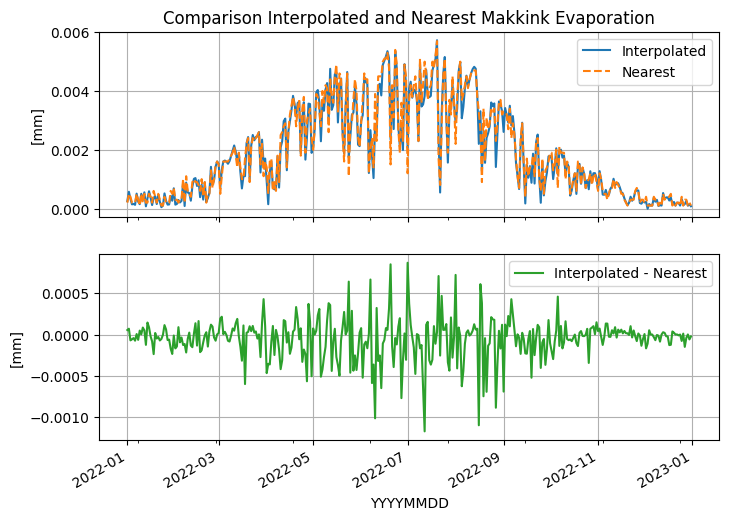

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
eti.plot(ax=ax[0])
etn.plot(ax=ax[0], linestyle="--", color="C1")
ax[0].set_title("Comparison Interpolated and Nearest Makkink Evaporation")
ax[0].set_ylabel("[mm]")
ax[0].grid()
ax[0].legend(["Interpolated", "Nearest"])

(eti.squeeze() - etn["EV24"].squeeze()).plot(ax=ax[1], color="C2")
ax[1].set_ylabel("[mm]")
ax[1].grid()
ax[1].legend(["Interpolated - Nearest"])

The interpolated evaporation can also be collected for multiple points (using x and y in a list of DataFrame) in an ObsCollection

In [35]:
oc_et = oc.interpolate(xy=[(100000, 320000), (100000, 330000), (100000, 340000)])
oc_et

,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
100000_320000,100000,320000,,,interpolation,,NaN,EV24,EvaporationObs 100000_320000 -----metadata----...
100000_330000,100000,330000,,,interpolation,,NaN,EV24,EvaporationObs 100000_330000 -----metadata----...
100000_340000,100000,340000,,,interpolation,,NaN,EV24,EvaporationObs 100000_340000 -----metadata----...


The interpolation method is slow at first, but if collected for many different locations the time penalty is not that significant anymore. 

## [Get transformed KNMI scenarios](#top)<a id=KNMITransformed></a>

You can read the transformed KNMI series for the 'KNMI '23 Klimaatscenario's' using `hpd.read_knmi_scenarios()`. This function downloads all available data for one station, but can also be limited to specific variables, years and scenarios. 

In [ ]:
oc = hpd.read_knmi_scenarios(550)

vars = list(dict.fromkeys([item.split('_')[0] for item in oc.index]))
n = len(vars)
cols = 3
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 4.5 * rows), sharex=False)
axes = axes.flatten()

handles_all = []
labels_all = []
for ax, var in zip(axes, vars):
    obs_names = [item for item in oc.index if var in item] 
    for obs_name in obs_names:
        o = oc.loc[obs_name, "obs"]
        obs_label = obs_name.split("_")[-1]
        line, = ax.plot(o.index, o.values, label=obs_label)
        handles_all.append(line)
        labels_all.append(obs_label)
    ax.set_title(var)
    ax.set_xlabel("Date")

for i in range(len(vars), len(axes)):
    axes[i].axis("off")

unique = dict(zip(labels_all, handles_all))

fig.legend(
    unique.values(),
    unique.keys(),
    loc='lower center',
    bbox_to_anchor=(1.66/2, 0.02),
    fontsize=12,
    frameon=True
)

for ax in axes:
    ax.set_xlim(pd.Timestamp("1991-01-01"), pd.Timestamp("2020-12-31"))

plt.tight_layout()
plt.show()

AttributeError: module 'hydropandas' has no attribute 'read_knmi_scenarios'